In [2]:
"""
dataset_summary.py
──────────────────
Scans all raw datasets (AVL stop-level, AVL trip-level, GTFS merged, Weather)
and prints a concise info report for the poster / presentation.

Run from: notebooks/ (so ../data/raw paths resolve correctly)
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW = Path('../data/raw')

SEP  = "═" * 72
SEP2 = "─" * 72

def fmt(n):
    """Format large integers with commas."""
    return f"{n:,}" if isinstance(n, (int, np.integer)) else str(n)

def file_mb(path):
    return path.stat().st_size / 1e6

def summarise_csv(path, nrows_sample=5000, label=None):
    """Load a sample of a CSV and return a tidy summary dict."""
    df = pd.read_csv(path, nrows=nrows_sample, low_memory=False)
    return {
        'label':    label or path.name,
        'columns':  df.columns.tolist(),
        'dtypes':   df.dtypes.to_dict(),
        'sample':   df,
        'n_cols':   len(df.columns),
    }

# ─────────────────────────────────────────────────────────────────────────────
# 1.  AVL — STOP-LEVEL  (monthly CSVs per route)
# ─────────────────────────────────────────────────────────────────────────────
print(SEP)
print("DATASET 1 — AVL Stop-Level Events")
print(SEP)

stop_level_dir = RAW / 'avl' / 'stop_level'
avl_routes = sorted([d.name for d in stop_level_dir.iterdir() if d.is_dir()])

avl_records = {}
avl_sample  = {}

for route in avl_routes:
    route_dir   = stop_level_dir / route
    csv_files   = sorted(route_dir.glob('*.csv'))
    total_mb    = sum(file_mb(f) for f in csv_files)
    n_months    = len(csv_files)

    # Count rows from all files efficiently (skip header)
    total_rows = sum(
        sum(1 for _ in open(f, 'rb')) - 1   # subtract header
        for f in csv_files
    )
    avl_records[route] = total_rows

    # Load one month as sample for column info
    sample_df = pd.read_csv(csv_files[0], nrows=3000, low_memory=False)
    avl_sample[route] = sample_df

    print(f"\n  Route {route}:")
    print(f"    Files         : {n_months} monthly CSVs  ({csv_files[0].name} … {csv_files[-1].name})")
    print(f"    Total size    : {total_mb:.1f} MB")
    print(f"    Total rows    : {fmt(total_rows)}")
    print(f"    Columns ({sample_df.shape[1]}): {sample_df.columns.tolist()}")
    print(f"    Date range    : {csv_files[0].stem[:6]} – {csv_files[-1].stem[:6]}")

# Column dtypes from first route sample
first_sample = list(avl_sample.values())[0]
print(f"\n  Column Dtypes (sample from first file):")
for col, dt in first_sample.dtypes.items():
    null_pct = first_sample[col].isna().mean() * 100
    print(f"    {col:<35} {str(dt):<12}  nulls: {null_pct:.1f}%")

print(f"\n  ── Combined Stop-Level Totals ──")
print(f"    Routes          : {', '.join(avl_routes)}")
print(f"    Total rows      : {fmt(sum(avl_records.values()))}")

# ─────────────────────────────────────────────────────────────────────────────
# 2.  AVL — TRIP-LEVEL  (transsee.csv)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("DATASET 2 — AVL Trip-Level (transsee.csv)")
print(SEP)

transsee_path = RAW / 'avl' / 'trip_level' / 'transsee.csv'
ts_size_gb    = transsee_path.stat().st_size / 1e9
ts_sample     = pd.read_csv(transsee_path, nrows=5000, low_memory=False)
ts_total_rows = sum(1 for _ in open(transsee_path, 'rb')) - 1

print(f"\n  File            : transsee.csv")
print(f"  Size            : {ts_size_gb:.2f} GB")
print(f"  Total rows      : {fmt(ts_total_rows)}")
print(f"  Columns ({ts_sample.shape[1]})  : {ts_sample.columns.tolist()}")
print(f"\n  Column Dtypes:")
for col, dt in ts_sample.dtypes.items():
    null_pct = ts_sample[col].isna().mean() * 100
    print(f"    {col:<35} {str(dt):<12}  nulls: {null_pct:.1f}%")

# ─────────────────────────────────────────────────────────────────────────────
# 3.  GTFS — MERGED (Routes 29 & 39)
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("DATASET 3 — GTFS Merged (Routes 29 & 39)")
print(SEP)

gtfs_dir     = RAW / 'gtfs' / 'gtfs_merged_29_39'
gtfs_files   = sorted(gtfs_dir.glob('*.csv'))

# How many raw GTFS feed snapshots exist
feed_dirs    = [d for d in (RAW / 'gtfs').iterdir() if d.is_dir() and d.name != 'gtfs_merged_29_39']
print(f"\n  Source GTFS feeds   : {len(feed_dirs)} snapshots")
print(f"  Feed date range     : {sorted(feed_dirs)[0].name} → {sorted(feed_dirs)[-1].name}")
print(f"\n  Merged GTFS files   :")

for f in gtfs_files:
    df = pd.read_csv(f, nrows=5000, low_memory=False)
    total_rows = sum(1 for _ in open(f, 'rb')) - 1
    size_kb    = file_mb(f) * 1000
    print(f"\n    [{f.name}]  rows: {fmt(total_rows)}  size: {size_kb:.0f} KB")
    print(f"      Columns: {df.columns.tolist()}")

# Key table deep-dives
print(f"\n  ── Key GTFS Table Details ──")

trips    = pd.read_csv(gtfs_dir / 'trips.csv',      dtype=str)
stops    = pd.read_csv(gtfs_dir / 'stops.csv',       dtype=str)
st       = pd.read_csv(gtfs_dir / 'stop_times.csv',  nrows=50000, low_memory=False)
routes_g = pd.read_csv(gtfs_dir / 'routes.csv',      dtype=str)
calendar = pd.read_csv(gtfs_dir / 'calendar.csv',    dtype=str)

print(f"\n  trips.csv")
print(f"    Total trips     : {fmt(len(trips))}")
print(f"    Routes covered  : {sorted(trips['route_id'].unique().tolist())}")
print(f"    Directions      : {trips['direction_id'].value_counts().to_dict()}")

print(f"\n  stops.csv")
print(f"    Total stops     : {fmt(len(stops))}")
lat_f = stops['stop_lat'].astype(float)
lon_f = stops['stop_lon'].astype(float)
print(f"    Lat range       : {lat_f.min():.4f} – {lat_f.max():.4f}")
print(f"    Lon range       : {lon_f.min():.4f} – {lon_f.max():.4f}")

print(f"\n  stop_times.csv  (sample of 50,000 rows)")
print(f"    Columns         : {st.columns.tolist()}")
total_st_rows = sum(1 for _ in open(gtfs_dir / 'stop_times.csv', 'rb')) - 1
print(f"    Total rows      : {fmt(total_st_rows)}")

print(f"\n  routes.csv")
print(routes_g[['route_id','route_short_name','route_long_name','route_type']].to_string(index=False))

print(f"\n  calendar.csv")
print(f"    Service IDs     : {len(calendar)}")
print(f"    Date range      : {calendar['start_date'].min()} – {calendar['end_date'].max()}")

# ─────────────────────────────────────────────────────────────────────────────
# 4.  WEATHER
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("DATASET 4 — Weather (Environment Canada)")
print(SEP)

weather_dir = RAW / 'weather'

# ── climate_combined.csv (Toronto City Centre, 2025 only) ──
cc = pd.read_csv(weather_dir / 'climate_combined.csv')
cc.columns = [c.lstrip('\ufeff').strip('"') for c in cc.columns]
cc['datetime'] = pd.to_datetime(cc['Date/Time (LST)'])

print(f"\n  File: climate_combined.csv  ({file_mb(weather_dir / 'climate_combined.csv'):.1f} MB)")
print(f"    Station         : {cc['Station Name'].iloc[0]}  (Climate ID: {cc['Climate ID'].iloc[0]})")
print(f"    Period          : {cc['datetime'].min().date()} → {cc['datetime'].max().date()}")
print(f"    Rows            : {fmt(len(cc))}  (hourly, {len(cc)/(365*24)*100:.1f}% coverage)")
print(f"    Columns ({cc.shape[1]})   : {cc.columns.tolist()}")
print(f"\n    Missing rates on key vars:")
KEY = ['Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)',
       'Wind Spd (km/h)', 'Visibility (km)', 'Precip. Amount (mm)']
for col in KEY:
    if col in cc.columns:
        pct = cc[col].isna().mean() * 100
        print(f"      {col:<30} {pct:.1f}%")

# ── weather_complete.csv (Toronto Pearson, 2014-2025) ──
wc = pd.read_csv(weather_dir / 'weather_complete.csv', low_memory=False)
wc['datetime'] = pd.to_datetime(wc['Date/Time (LST)'])

print(f"\n  File: weather_complete.csv  ({file_mb(weather_dir / 'weather_complete.csv'):.1f} MB)")
print(f"    Station         : {wc['Station Name'].iloc[0]}  (Climate ID: {wc['Climate ID'].iloc[0]})")
print(f"    Period          : {wc['datetime'].min().date()} → {wc['datetime'].max().date()}")
print(f"    Years covered   : {sorted(wc['Year'].unique().tolist())}")
print(f"    Rows            : {fmt(len(wc))}")
wc25 = wc[wc['Year'] == 2025]
print(f"    2025 rows       : {fmt(len(wc25))}  ({len(wc25)/(365*24)*100:.1f}% hourly coverage)")
print(f"    Columns ({wc.shape[1]})   : {wc.columns.tolist()}")
print(f"\n    Missing rates on key vars (full dataset):")
for col in KEY:
    if col in wc.columns:
        pct = wc[col].isna().mean() * 100
        print(f"      {col:<30} {pct:.1f}%")

# ─────────────────────────────────────────────────────────────────────────────
# 5.  OVERALL SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("OVERALL DATASET SUMMARY — Table 1")
print(SEP)

summary_rows = []

# AVL stop-level
for route in avl_routes:
    route_dir  = stop_level_dir / route
    csv_files  = sorted(route_dir.glob('*.csv'))
    total_mb   = sum(file_mb(f) for f in csv_files)
    summary_rows.append({
        'Dataset':      f'AVL Stop-Level Rt {route}',
        'Source':       'TTC AVL system',
        'Format':       'CSV (monthly)',
        'Files':        len(csv_files),
        'Rows':         fmt(avl_records[route]),
        'Columns':      avl_sample[route].shape[1],
        'Period':       '2025 (Jan–Dec)',
        'Size (MB)':    f'{total_mb:.0f}',
    })

# AVL trip-level
summary_rows.append({
    'Dataset':    'AVL Trip-Level (transsee)',
    'Source':     'TTC Transsee',
    'Format':     'CSV (single file)',
    'Files':      1,
    'Rows':       fmt(ts_total_rows),
    'Columns':    ts_sample.shape[1],
    'Period':     '2025',
    'Size (MB)':  f'{ts_size_gb*1000:.0f}',
})

# GTFS merged
summary_rows.append({
    'Dataset':    'GTFS Merged (Rt 29 & 39)',
    'Source':     'TTC GTFS feeds',
    'Format':     'CSV (11 files)',
    'Files':      len(gtfs_files),
    'Rows':       f'{len(trips):,} trips / {len(stops):,} stops',
    'Columns':    '—',
    'Period':     f'{sorted(feed_dirs)[0].name[10:18]} → {sorted(feed_dirs)[-1].name[10:18]}',
    'Size (MB)':  f'{sum(file_mb(f) for f in gtfs_files):.0f}',
})

# Weather
summary_rows.append({
    'Dataset':    'Weather – City Centre (2025)',
    'Source':     'Environment Canada',
    'Format':     'CSV',
    'Files':      1,
    'Rows':       fmt(len(cc)),
    'Columns':    cc.shape[1],
    'Period':     '2025 (Jan–Dec)',
    'Size (MB)':  f'{file_mb(weather_dir / "climate_combined.csv"):.1f}',
})
summary_rows.append({
    'Dataset':    'Weather – Pearson (2014–2025)',
    'Source':     'Environment Canada',
    'Format':     'CSV',
    'Files':      1,
    'Rows':       fmt(len(wc)),
    'Columns':    wc.shape[1],
    'Period':     '2014–2025',
    'Size (MB)':  f'{file_mb(weather_dir / "weather_complete.csv"):.1f}',
})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

print(f"\n{SEP2}")
print("Done. All datasets scanned successfully.")
print(SEP2)

════════════════════════════════════════════════════════════════════════
DATASET 1 — AVL Stop-Level Events
════════════════════════════════════════════════════════════════════════

  Route 116:
    Files         : 12 monthly CSVs  (202501_rt116.csv … 202512_rt116.csv)
    Total size    : 2162.7 MB
    Total rows    : 33,468,575
    Columns (9): ['20250101', '1', '1249', '116', '13', '43.739010', '-79.238258', '49775431', 'EMPTY']
    Date range    : 202501 – 202512

  Route 29:
    Files         : 12 monthly CSVs  (202501_rt29.csv … 202512_rt29.csv)
    Total size    : 2594.9 MB
    Total rows    : 40,639,420
    Columns (9): ['20250101', '1', '7218', '29', '87', '43.670430', '-79.439804', '49782614', 'EMPTY']
    Date range    : 202501 – 202512

  Route 39:
    Files         : 12 monthly CSVs  (202501_rt39.csv … 202512_rt39.csv)
    Total size    : 2543.4 MB
    Total rows    : 39,663,097
    Columns (9): ['20250101', '0', '3193', '39', '84', '43.793930', '-79.349701', '49786855', 'EM

route  hour_of_day  median_delay_sec
   29            0             102.0
   29            1              74.0
   29            2             101.0
   29            5              81.0
   29            6             114.0
   29            7             152.0
   29            8             156.0
   29            9             142.0
   29           10             160.0
   29           11             151.0
   29           12             164.0
   29           13             150.0
   29           14             148.0
   29           15             146.0
   29           16             152.0
   29           17             135.0
   29           18             135.0
   29           19             136.0
   29           20             136.0
   29           21             117.0
   29           22              97.0
   29           23              95.0
   39            0             123.0
   39            1              97.0
   39            2              90.0
   39            4              62.0
 

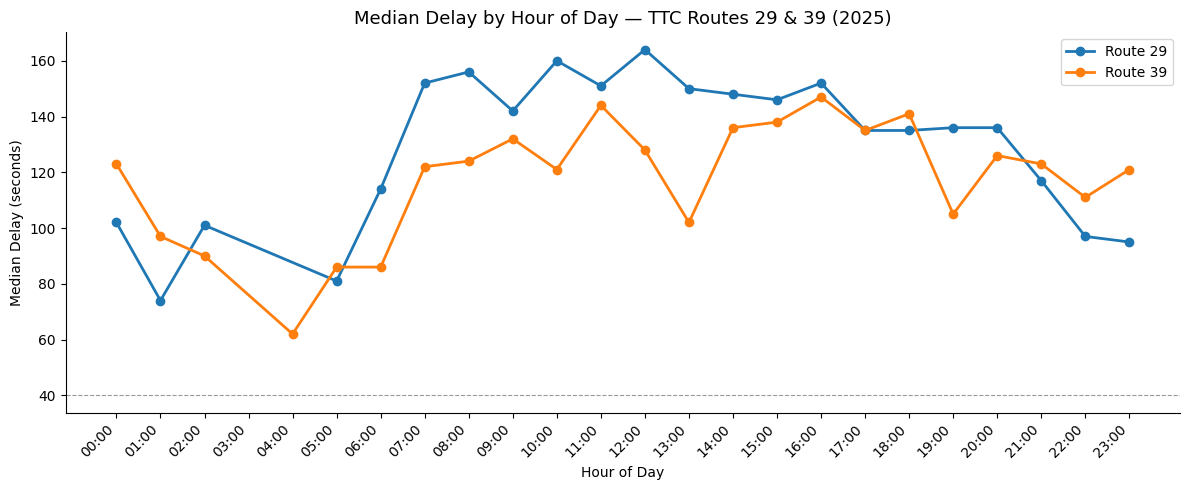

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_parquet('../data/processed/stop_delays/delays_all_routes_2025.parquet')

# ── Extract hour of day ────────────────────────────────────────────────────
df['timestamp'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['sched_arrival_sec'], unit='s')
df['hour_of_day'] = df['timestamp'].dt.hour

# ── Compute median delay by route × hour ──────────────────────────────────
hourly = (
    df.groupby(['route', 'hour_of_day'])['delay_sec']
    .median()
    .reset_index()
    .rename(columns={'delay_sec': 'median_delay_sec'})
)

print(hourly.to_string(index=False))

# ── Plot ───────────────────────────────────────────────────────────────────
COLORS = {'29': '#1f77b4', '39': '#ff7f0e'}

fig, ax = plt.subplots(figsize=(12, 5))

for route, grp in hourly.groupby('route'):
    ax.plot(
        grp['hour_of_day'],
        grp['median_delay_sec'],
        marker='o', linewidth=2,
        color=COLORS[str(route)],
        label=f'Route {route}'
    )

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Median Delay (seconds)')
ax.set_title('Median Delay by Hour of Day — TTC Routes 29 & 39 (2025)', fontsize=13)
ax.axhline(40, color='black', ls='--', lw=0.8, alpha=0.4)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('median_delay_by_hour.png', dpi=150)
plt.show()